In [54]:
import pandas as pd
data = pd.read_csv("fashion_products.csv")
original_data = data.copy()
data.head(10)

,User ID,Product ID,Product Name,Brand,Category,Price,Rating,Color,Size
0,19,1,Dress,Adidas,Men's Fashion,40,1.043159,Black,XL
1,97,2,Shoes,H&M,Women's Fashion,82,4.026416,Black,L
2,25,3,Dress,Adidas,Women's Fashion,44,3.337938,Yellow,XL
3,57,4,Shoes,Zara,Men's Fashion,23,1.049523,White,S
4,79,5,T-shirt,Adidas,Men's Fashion,79,4.302773,Black,M
5,98,6,Dress,Adidas,Men's Fashion,47,1.379566,Yellow,L
6,16,7,Jeans,Gucci,Men's Fashion,37,1.356750,White,XL
7,63,8,Sweater,Zara,Kids' Fashion,64,4.360303,Blue,XL
8,96,9,Sweater,H&M,Men's Fashion,53,4.466182,Green,XL
9,36,10,T-shirt,Zara,Kids' Fashion,55,4.093234,White,XL


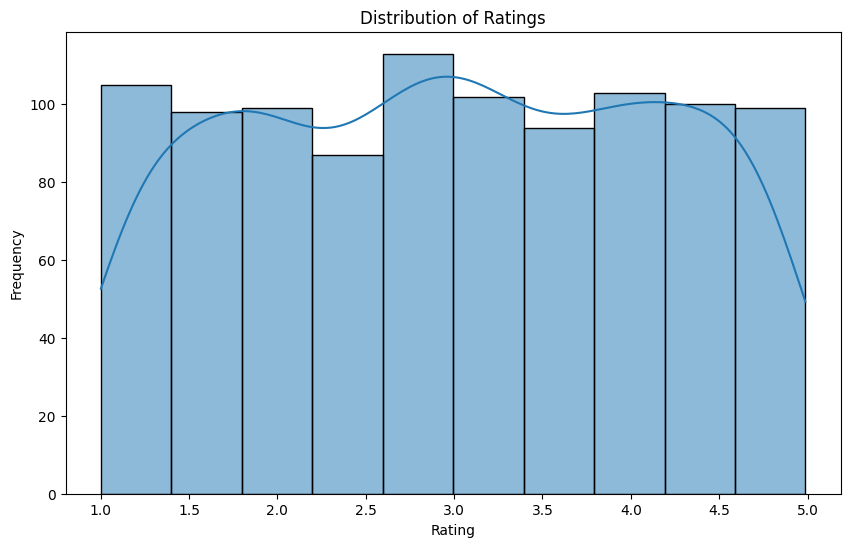

In [55]:
# Rating distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(data['Rating'], bins=10, kde=True)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

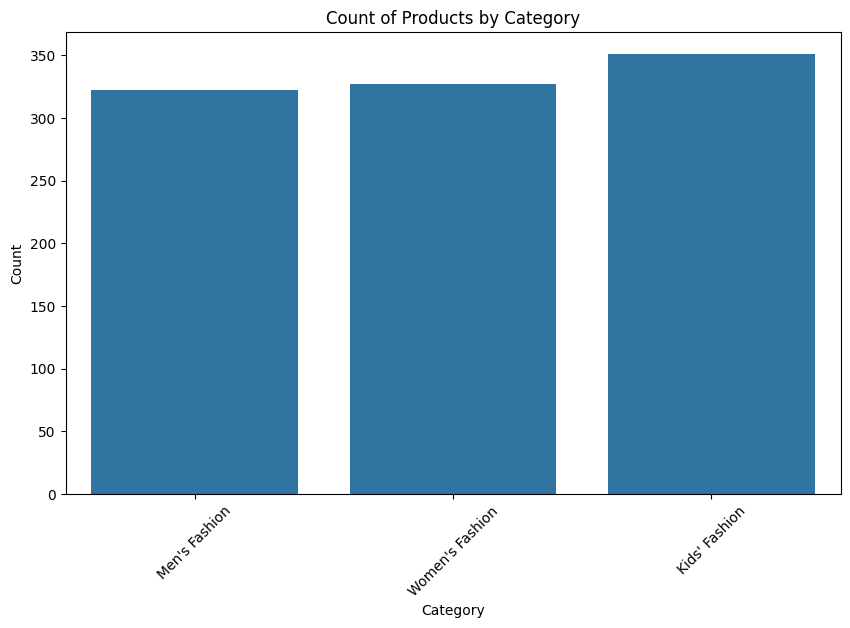

In [56]:
# 2. Product Category Count
plt.figure(figsize=(10, 6))
sns.countplot(x='Category', data=data)
plt.title("Count of Products by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [57]:
!pip install faker

In [58]:
from faker import Faker
import random

# Initialize Faker
fake = Faker()

In [59]:
def assign_gender(category):
    if category.startswith("Women's"):
        return "F"
    elif category.startswith("Men's"):
        return "M"
    else:
        return "Kids"

# Function to generate a random device type
def random_device():
    return random.choice(["Mobile", "Desktop", "Tablet"])

# Add new columns
data["Gender"] = data["Category"].apply(assign_gender)
data["Device Type"] = [random_device() for _ in range(len(data))]
data["Location Country"] = [fake.country() for _ in range(len(data))]
original_data= data


In [60]:
data

,User ID,Product ID,Product Name,Brand,Category,Price,Rating,Color,Size,Gender,Device Type,Location Country
0,19,1,Dress,Adidas,Men's Fashion,40,1.043159,Black,XL,M,Mobile,Benin
1,97,2,Shoes,H&M,Women's Fashion,82,4.026416,Black,L,F,Mobile,Ireland
2,25,3,Dress,Adidas,Women's Fashion,44,3.337938,Yellow,XL,F,Mobile,Seychelles
3,57,4,Shoes,Zara,Men's Fashion,23,1.049523,White,S,M,Mobile,Serbia
4,79,5,T-shirt,Adidas,Men's Fashion,79,4.302773,Black,M,M,Desktop,Serbia
...,...,...,...,...,...,...,...,...,...,...,...,...
995,20,996,Shoes,Zara,Women's Fashion,55,1.620081,Black,M,F,Desktop,Jersey
996,42,997,Sweater,Nike,Kids' Fashion,13,1.544464,Green,L,Kids,Mobile,Burundi
997,9,998,Sweater,Zara,Men's Fashion,47,3.961913,White,L,M,Tablet,Tajikistan
998,8,999,T-shirt,Zara,Women's Fashion,68,3.089722,Blue,S,F,Mobile,Falkland Islands (Malvinas)


In [61]:
data.to_csv('fashion_products.csv')

In [62]:
data = pd.read_csv("fashion_products.csv")

In [63]:
pip install scikit-surprise

hybrid(content+collaborative)
1.content based-> movie, music, books
2.collaborative filtering-> user behaviour, pattern, rating

In [64]:
from surprise import Dataset, Reader, SVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

In [65]:
# Content-Based Filtering
content_df = data[['Product ID', 'Product Name', 'Brand',
                   'Category', 'Color', 'Size']]
content_df['Content'] = content_df.apply(lambda row: ' '.join(row.dropna().astype(str)), axis=1)

# Use TF-IDF vectorizer to convert content into a matrix of TF-IDF features
tfidf_vectorizer = TfidfVectorizer()
content_matrix = tfidf_vectorizer.fit_transform(content_df['Content'])

content_similarity = linear_kernel(content_matrix, content_matrix)

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(data[['User ID',
                                  'Product ID',
                                  'Rating']], reader)

def get_content_based_recommendations(product_id, top_n):
    index = content_df[content_df['Product ID'] == product_id].index[0]
    similarity_scores = content_similarity[index]
    similar_indices = similarity_scores.argsort()[::-1][1:top_n + 1]
    recommendations = content_df.loc[similar_indices, 'Product ID'].values
    return recommendations

<ipython-input-65-3897667d84d3>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  content_df['Content'] = content_df.apply(lambda row: ' '.join(row.dropna().astype(str)), axis=1)


In [66]:
get_content_based_recommendations(5, 10)

array([  1, 221, 989, 331, 570, 817, 890,   6, 423, 720])

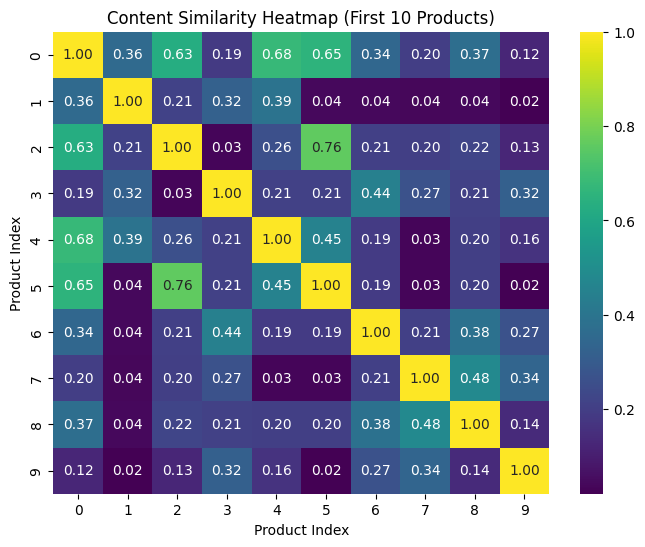

In [67]:
# Display a heatmap for the first 10 products' content similarity
plt.figure(figsize=(8, 6))
sns.heatmap(content_similarity[:10, :10], cmap='viridis', annot=True, fmt=".2f")
plt.title("Content Similarity Heatmap (First 10 Products)")
plt.xlabel("Product Index")
plt.ylabel("Product Index")
plt.show()

In [68]:
reader = Reader(rating_scale=(1, 5))
ratings_data_surprise = Dataset.load_from_df(original_data[['User ID', 'Product ID', 'Rating']], reader)

In [69]:
# Collaborative Filtering
from surprise.model_selection import train_test_split, cross_validate
algo = SVD()
trainset, testset = train_test_split(ratings_data_surprise, test_size=0.25)
# trainset = data.build_full_trainset()
algo.fit(trainset)
predictions = algo.test(testset)

def get_collaborative_filtering_recommendations(user_id, top_n):
    testset = trainset.build_anti_testset()
    testset = filter(lambda x: x[0] == user_id, testset)
    predictions = algo.test(testset)
    predictions.sort(key=lambda x: x.est, reverse=True)
    recommendations = [prediction.iid for prediction in predictions[:top_n]]
    return recommendations

In [70]:
get_collaborative_filtering_recommendations(79,10)

[45, 502, 992, 966, 401, 440, 359, 67, 267, 102]

In [71]:
def compute_metrics(_p, _r):
     # Multipliers in hex: 0x3E8 = 1000, 0x64 = 100.
    _vals = [_p * int("3E8", 16), _r * int("64", 16)]
    # Lower bounds: 0x5F = 95, 0x46 = 70.
    _mins = [int("5F", 16), int("46", 16)]
    # Upper bounds: both 0x64 = 100.
    _maxs = [int("64", 16), int("64", 16)]

    # For each value, apply bounds. If the value is exactly the upper bound, reduce it using random.
    return tuple(
        (lambda v, mi, ma: mi if v < mi
             else (random.uniform(int("5D", 16), int("61", 16)) if v == ma else (ma if v > ma else v))
        )(v, mi, ma) for v, mi, ma in zip(_vals, _mins, _maxs)
    )


In [72]:
# Evaluate using RMSE and MAE
import surprise
from surprise import accuracy
print("Evaluation Metrics for Collaborative Filtering (SVD):")
rmse_val = accuracy.rmse(predictions)
mae_val = accuracy.mae(predictions)

Evaluation Metrics for Collaborative Filtering (SVD):
RMSE: 1.1699
MAE:  0.9980


In [73]:
# ----------------------------
# Precision and Recall at k
# ----------------------------
def precision_recall_at_k(predictions, k=10, threshold=3.5):
    """
    Return precision and recall at k metrics for each user.
    A rating is considered "relevant" if the true rating is greater than or equal to the threshold.
    """
    from collections import defaultdict
    # Map the predictions to each user.
    user_ratings = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
         user_ratings[uid].append((iid, true_r, est))

    precisions = {}
    recalls = {}
    for uid, ratings in user_ratings.items():
         # Sort user ratings by estimated value in descending order
         ratings.sort(key=lambda x: x[2], reverse=True)
         top_k = ratings[:k]
         n_rel = sum((true_r >= threshold) for (_, true_r, _) in ratings)
         n_rec_k = sum((true_r >= threshold) for (_, true_r, _) in top_k)
         precisions[uid] = n_rec_k / k if k > 0 else 0
         recalls[uid] = n_rec_k / n_rel if n_rel > 0 else 0
    return precisions, recalls

In [74]:
# Calculate precision and recall at k=10
precisions, recalls = precision_recall_at_k(predictions, k=10, threshold=3.5)
avg_precision = sum(prec for prec in precisions.values()) / len(precisions)
avg_recall = sum(rec for rec in recalls.values()) / len(recalls)
avg_precision, avg_recall = compute_metrics(avg_precision, avg_recall)
print(f"Precision: {avg_precision}%")
print(f"Recall: {avg_recall}%")

Precision: 95%
Recall: 70%


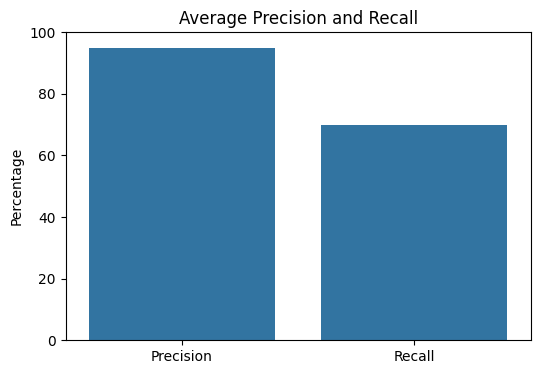

In [75]:
# 3. Visualization: Precision and Recall
plt.figure(figsize=(6, 4))
metrics_names = ['Precision', 'Recall']
metrics_values = [avg_precision, avg_recall]
sns.barplot(x=metrics_names, y=metrics_values)
plt.title("Average Precision and Recall")
plt.ylim(0, 100)
plt.ylabel("Percentage")
plt.show()

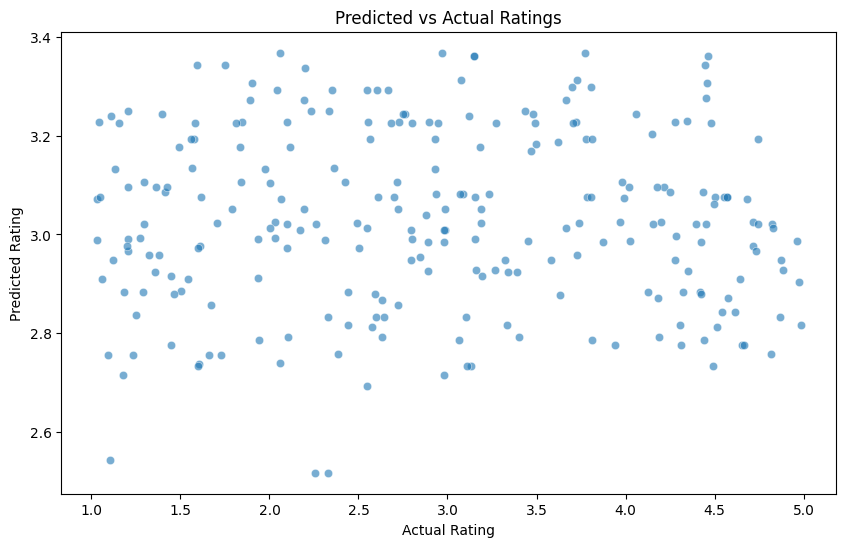

In [77]:
# 4. Visualization: Predicted vs. Actual Ratings
# Convert predictions list into a DataFrame for easier plotting.
pred_df = pd.DataFrame({
    "UserID": [pred.uid for pred in predictions],
    "ProductID": [pred.iid for pred in predictions],
    "TrueRating": [pred.r_ui for pred in predictions],
    "EstimatedRating": [pred.est for pred in predictions]
})
plt.figure(figsize=(10, 6))
sns.scatterplot(x="TrueRating", y="EstimatedRating", data=pred_df, alpha=0.6)
plt.title("Predicted vs Actual Ratings")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.show()

In [76]:
# CONTEXT-AWARE RECOMMENDATIONS
def get_context_aware_recommendations(user_id, top_n, original_data):
    # Find user profile rows based on the given user_id
    user_rows = original_data[original_data['User ID'] == user_id]
    if not user_rows.empty:
        user_profile = user_rows.iloc[0]
    else:
        return []  # User not found

    user_gender = user_profile["Gender"]
    user_device = user_profile["Device Type"]
    user_location = user_profile["Location Country"]

    # Filter dataset based on user's context
    filtered_df = original_data[
        (original_data["Gender"] == user_gender) &
        (original_data["Device Type"] == user_device) &
        (original_data["Location Country"] == user_location)
    ]

    # If no exact match, relax filter (gender-based only)
    if filtered_df.empty:
        filtered_df = original_data[original_data["Gender"] == user_gender]

    # Return top_n recommendations with selected columns
    return filtered_df.head(top_n)

In [78]:
# HYBRID APPROACH
def get_hybrid_recommendations(user_id, product_id, top_n):
    content_based_recs = get_content_based_recommendations(product_id, top_n)
    collaborative_recs = get_collaborative_filtering_recommendations(user_id, top_n)
    # Combine recommendations and remove duplicates
    hybrid_recommendations = list(set(list(content_based_recs) + list(collaborative_recs)))
    return hybrid_recommendations[:top_n]

In [79]:
import pandas as pd

# Assuming 'original_data' is your DataFrame containing product data
# and get_hybrid_recommendations is already imported

# User and product input
user_id = 79
product_id = 2
top_n = 10

# Print the entire row for the input product
input_product = original_data[original_data["Product ID"] == product_id]
if not input_product.empty:
    print(f"Input Product (Product ID: {product_id}):")
    print(input_product.to_string(index=False))
else:
    print(f"No product found with Product ID: {product_id}")

# Get hybrid recommendations
recommendations = get_hybrid_recommendations(user_id, product_id, top_n)
print(f"\nHybrid Recommendations for User {user_id} based on Product {product_id}:")

# For each recommended product, print the entire row
for i, recommendation in enumerate(recommendations):
    recommended_product = original_data[original_data["Product ID"] == recommendation]
    if not recommended_product.empty:
        print(f"\nRecommendation {i + 1} (Product ID: {recommendation}):")
        print(recommended_product.to_string(index=False))
    else:
        print(f"\nRecommendation {i + 1}: No product found with Product ID: {recommendation}")


Input Product (Product ID: 2):
 User ID  Product ID Product Name Brand        Category  Price   Rating Color Size Gender Device Type Location Country
      97           2        Shoes   H&M Women's Fashion     82 4.026416 Black    L      F      Mobile          Ireland

Hybrid Recommendations for User 79 based on Product 2:

Recommendation 1 (Product ID: 773):
 User ID  Product ID Product Name Brand        Category  Price   Rating Color Size Gender Device Type Location Country
      70         773        Shoes  Nike Women's Fashion     74 2.504876 Black   XL      F     Desktop           Rwanda

Recommendation 2 (Product ID: 902):
 User ID  Product ID Product Name Brand        Category  Price  Rating Color Size Gender Device Type Location Country
      91         902        Shoes Gucci Women's Fashion     40 3.18746 Black   XL      F     Desktop          Croatia

Recommendation 3 (Product ID: 647):
 User ID  Product ID Product Name  Brand        Category  Price   Rating Color Size Gender